In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("C:/Users/asingh83/OneDrive - WM/Documents/Projects(Data Science)/Data sets/customer_booking.csv", encoding="latin1")

In [3]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [4]:
df.shape

(50000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [6]:
df.isnull().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(719)

In [8]:
df['booking_complete'].value_counts()

booking_complete
0    42522
1     7478
Name: count, dtype: int64

In [9]:
df['booking_complete'].value_counts(normalize=True)

booking_complete
0    0.85044
1    0.14956
Name: proportion, dtype: float64

#### Drop_duplicates

In [10]:
df = df.drop_duplicates().copy()

In [11]:
df.shape

(49281, 14)

In [12]:
df.duplicated().sum()

np.int64(0)

#### Exploratory Data Analysis (EDA)

In [13]:
#How many customers complete bookings after removing duplicates?
df["booking_complete"].value_counts() 

booking_complete
0    41890
1     7391
Name: count, dtype: int64

In [14]:
df["booking_complete"].value_counts(normalize=True) * 100

booking_complete
0    85.002334
1    14.997666
Name: proportion, dtype: float64

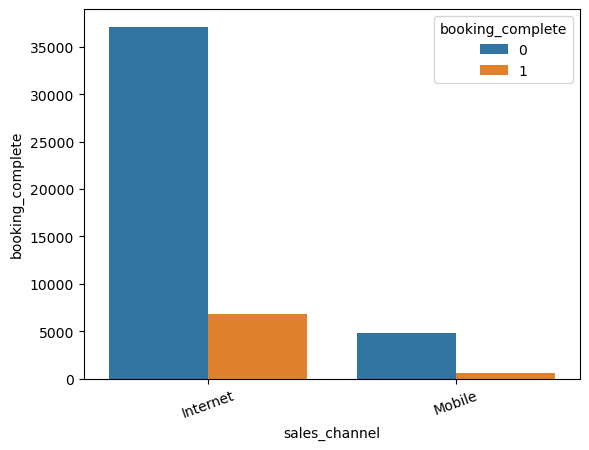

In [15]:
# Does the way a customer makes the booking (sales_channel) relate to booking completion?
Booking_complete = pd.crosstab(
    df["sales_channel"],
    df["booking_complete"],
    normalize="index"
) * 100

Booking_complete

sns.countplot(
    data=df,
    x="sales_channel",
    hue="booking_complete"
)
plt.xlabel("sales_channel")
plt.ylabel("booking_complete")
plt.xticks(rotation=20)
plt.show()

In [16]:
# Trip Type vs Booking Completion
pd.crosstab(
    df["trip_type"],
    df["booking_complete"],
    normalize="index"
) * 100

booking_complete,0,1
trip_type,,
CircleTrip,95.689655,4.310345
OneWay,94.818653,5.181347
RoundTrip,84.899239,15.100761


In [17]:
#Does the number of days between booking and flight affect booking completion?
df["purchase_lead"].describe()

count    49281.000000
mean        84.723281
std         90.410229
min          0.000000
25%         21.000000
50%         51.000000
75%        115.000000
max        867.000000
Name: purchase_lead, dtype: float64

In [18]:
#Does purchase lead affect booking completion?
#Let's compare average purchase lead for completed vs non-completed bookings.
df.groupby("booking_complete")["purchase_lead"].mean()

booking_complete
0    85.563762
1    79.959681
Name: purchase_lead, dtype: float64

In [19]:
df["purchase_lead_group"] = pd.cut(
    df["purchase_lead"],
    bins=[-1, 7, 30, 90, 180, float("inf")],
    labels=["0-7 days", "8-30 days", "31-90 days", "91-180 days", "180+ days"]
)

pd.crosstab(
    df["purchase_lead_group"],
    df["booking_complete"],
    normalize="index"
) * 100

booking_complete,0,1
purchase_lead_group,,
0-7 days,82.663317,17.336683
8-30 days,83.882604,16.117396
31-90 days,85.397147,14.602853
91-180 days,86.501834,13.498166
180+ days,85.782725,14.217275


In [20]:
#length_of_stay — how many days the customer plans to stay.
df["length_of_stay"].describe()

count    49281.000000
mean        23.053976
std         33.832149
min          0.000000
25%          5.000000
50%         17.000000
75%         28.000000
max        778.000000
Name: length_of_stay, dtype: float64

In [21]:
df.groupby("booking_complete")["length_of_stay"].mean()

booking_complete
0    23.651969
1    19.664727
Name: length_of_stay, dtype: float64

In [22]:
df["length_of_stay_group"] = pd.cut(
    df["length_of_stay"],
    bins=[-1, 3, 7, 14, 30, 60, float("inf")],
    labels=[
        "0-3 days",
        "4-7 days",
        "8-14 days",
        "15-30 days",
        "31-60 days",
        "60+ days"
    ]
)

pd.crosstab(
    df["length_of_stay_group"],
    df["booking_complete"],
    normalize="index"
) * 100

booking_complete,0,1
length_of_stay_group,,
0-3 days,82.172915,17.827085
4-7 days,80.472209,19.527791
15-30 days,89.875230,10.124770
31-60 days,89.802059,10.197941
60+ days,85.350791,14.649209


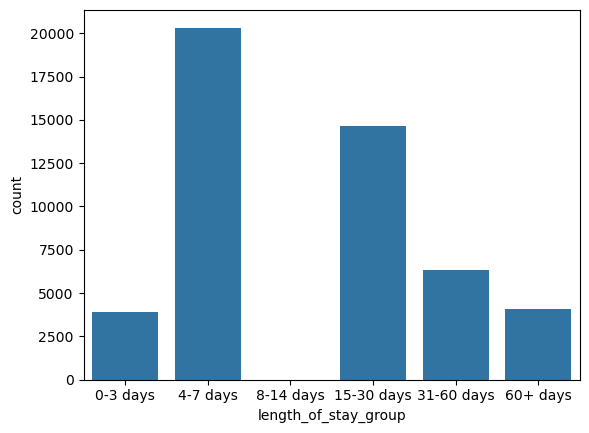

In [23]:
sns.countplot(x=df["length_of_stay_group"])
plt.show()

0–3, 4–7, 8–14 is missing, then 15–30.

That's because your output doesn't show the 8-14 days category. Most likely there are no records in that range (or pandas omitted an unused categorical level).

In [24]:
df["length_of_stay_group"].value_counts().sort_index()

length_of_stay_group
0-3 days       3921
4-7 days      20330
8-14 days         0
15-30 days    14667
31-60 days     6315
60+ days       4048
Name: count, dtype: int64

In [25]:
#Does the departure time of the flight relate to booking completion?
df["flight_hour"].describe()

count    49281.000000
mean         9.070676
std          5.413099
min          0.000000
25%          5.000000
50%          9.000000
75%         13.000000
max         23.000000
Name: flight_hour, dtype: float64

In [26]:
df.groupby("booking_complete")["flight_hour"].mean()
#flight_hour does not appear to have a meaningful relationship with booking completion.

booking_complete
0    9.055431
1    9.157083
Name: flight_hour, dtype: float64

In [27]:
#Flight Day
#Now let's check whether the day of the week affects booking completion.
pd.crosstab(
    df["flight_day"],
    df["booking_complete"],
    normalize="index"
) * 100

booking_complete,0,1
flight_day,,
Fri,85.400150,14.599850
Mon,85.052579,14.947421
Sat,85.060283,14.939717
Sun,85.858429,14.141571
Thu,84.855933,15.144067
Tue,85.234189,14.765811
Wed,83.734462,16.265538


The rates are all between roughly 14.1% and 16.3%.

Wednesday is highest at 16.27%, while Sunday is lowest at 14.14%.

That's only about a 2.1 percentage-point difference

In [28]:
#Flight Duration
df["flight_duration"].describe()

count    49281.000000
mean         7.279974
std          1.496390
min          4.670000
25%          5.620000
50%          7.570000
75%          8.830000
max          9.500000
Name: flight_duration, dtype: float64

In [29]:
#Does flight duration differ between completed and non-completed bookings?
df.groupby("booking_complete")["flight_duration"].mean()

booking_complete
0    7.346932
1    6.900475
Name: flight_duration, dtype: float64

In [30]:
#Customer preferences
#It's already a binary feature, so no feature engineering is needed.
df.groupby("wants_extra_baggage")["booking_complete"].mean() * 100

wants_extra_baggage
0    11.529052
1    16.719808
Name: booking_complete, dtype: float64

Customers who selected extra baggage completed their bookings more often:

16.72% vs 11.53% — a difference of about 5.19 percentage points.

In [31]:
#Preferred Seat
#It's already a binary feature, so no feature engineering is needed.
df.groupby("wants_preferred_seat")["booking_complete"].mean() * 100

wants_preferred_seat
0    13.836714
1    17.763745
Name: booking_complete, dtype: float64

Customers who selected a preferred seat had a 3.93 percentage-point higher completion rate.

There is a noticeable positive relationship:

##### Customers showing additional preferences during booking tend to have a higher likelihood of completing the booking.

We've now checked two useful behavioural variables:

🧳 Extra baggage → 16.72%
💺 Preferred seat → 17.76%

In [32]:
#flight meals
df.groupby("wants_in_flight_meals")["booking_complete"].mean() * 100

wants_in_flight_meals
0    14.184598
1    16.090369
Name: booking_complete, dtype: float64

Customers wanting in-flight meals have a 1.91 percentage-point higher completion rate.

In [33]:
#Number of passengers
df.groupby("num_passengers")["booking_complete"].mean() * 100

num_passengers
1    14.258881
2    16.015471
3    16.863289
4    15.449915
5    19.485294
6    18.861210
7    14.953271
8    13.636364
9    20.312500
Name: booking_complete, dtype: float64

#### route and booking_origin
These are categorical variables with potentially many unique values, so we shouldn't blindly one-hot encode them without first understanding their cardinality.

In [34]:
df["route"].nunique(), df["booking_origin"].nunique()

(799, 104)

If we one-hot encode route directly, we'd potentially create 799 additional columns. That's not automatically wrong—49K rows can handle it—but it makes the model more complex and can make feature interpretation less clean.

In [35]:
df["route"].value_counts().head(10)

route
AKLKUL    2620
PENTPE     912
MELSGN     833
ICNSIN     793
DMKKIX     729
ICNSYD     683
DMKPER     677
DPSICN     658
DMKOOL     652
MELTPE     637
Name: count, dtype: int64

In [36]:
#Let's calculate the number of bookings and completion rate for the top 10 routes:
id="8j1z9x"
route_analysis = (
    df.groupby("route")["booking_complete"]
      .agg(["count", "mean"])
      .sort_values("count", ascending=False)
      .head(10)
)

route_analysis["mean"] = route_analysis["mean"] * 100
route_analysis

,count,mean
route,,
AKLKUL,2620,21.335878
PENTPE,912,43.421053
MELSGN,833,5.162065
ICNSIN,793,11.223203
DMKKIX,729,25.377229
ICNSYD,683,0.732064
DMKPER,677,5.465288
DPSICN,658,8.662614
DMKOOL,652,6.134969


In [37]:
#booking_origin
df["booking_origin"].value_counts().head(10)

booking_origin
Australia      17691
Malaysia        7055
South Korea     4502
Japan           3819
China           3284
Indonesia       2317
Taiwan          2042
Thailand        1993
India           1258
New Zealand     1060
Name: count, dtype: int64

In [38]:
#Let's check completion rate for the 10 most common origins:
origin_analysis = (
    df.groupby("booking_origin")["booking_complete"]
      .agg(["count", "mean"])
      .sort_values("count", ascending=False)
      .head(10)
)

origin_analysis["mean"] = origin_analysis["mean"] * 100
origin_analysis

,count,mean
booking_origin,,
Australia,17691,5.059070
Malaysia,7055,34.500354
South Korea,4502,10.195469
Japan,3819,12.359256
China,3284,20.828258
Indonesia,2317,26.283988
Taiwan,2042,10.773751
Thailand,1993,23.281485
India,1258,10.174881


purchase_lead_group, 
length_of_stay_group

Those were EDA-only, not purposeful ML features.

In [39]:
df = df.drop(columns=["purchase_lead_group", "length_of_stay_group"]) 

In [40]:
df.shape

(49281, 14)

##### ML step: separating the input features from our target.

In [41]:
X = df.drop("booking_complete", axis=1)
y = df["booking_complete"]

In [42]:
X.shape, y.shape

((49281, 13), (49281,))

### Next: Train-Test Split

Training set → model learns from this


Testing set → we use this later to evaluate how well the model performs on unseen data.


Because our target has roughly 85% not completed / 15% completed, we should use stratification.

In [43]:
stratify=y

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

##### Next step: identify numeric vs categorical features

Our 13 input features contain both:

Numerical: num_passengers, purchase_lead, length_of_stay, flight_hour, wants_extra_baggage, etc.
    
Categorical: sales_channel, trip_type, flight_day, route, booking_origin

In [45]:
X_train.dtypes

num_passengers             int64
sales_channel             object
trip_type                 object
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                object
route                     object
booking_origin            object
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
dtype: object

##### One important thing
wants_extra_baggage,
wants_preferred_seat,
wants_in_flight_meals,
they're binary variables (0/1).

In [46]:
#Let's explicitly create our two feature lists.
#ColumnTransformer preprocessing pipeline

numeric_features = [
    "num_passengers",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "wants_extra_baggage",
    "wants_preferred_seat",
    "wants_in_flight_meals",
    "flight_duration"
]

categorical_features = [
    "sales_channel",
    "trip_type",
    "flight_day",
    "route",
    "booking_origin"
]

##### Why use a pipeline?

Instead of manually encoding columns and potentially making mistakes, we'll tell Scikit-learn:

"For these columns, apply one process. For those columns, apply another."

handle_unknown="ignore" → prevents errors if the test set contains a category not seen during training.

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [48]:
#ML concept: fitting the preprocessor only on the training data.
#That's part of avoiding data leakage.

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

#Training:

X_train
   ↓
fit_transform()
   ↓
Learn categories + encode

#Testing:

X_test
   ↓
transform()
   ↓
Use the encoding learned from X_train

##### fit_transform() → training data


##### transform() → test data

In [49]:
X_train_processed.shape, X_test_processed.shape

((39424, 901), (9857, 901))

In [50]:
#Why did 13 become 901?
#route → 799 unique categories
#booking_origin → 104 unique categories
#Plus categories from sales_channel, trip_type, and flight_day
#Plus our 8 numeric features
#799 + 104 + other categorical categories + 8 numeric = 901

#### Now we're ready for the model
### Random Forest
It works well with nonlinear relationships.
It doesn't require feature scaling.
Most importantly for the Forage assignment, we can examine feature importance afterward.

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

n_estimators=200 → builds 200 decision trees. More trees generally make the model more stable.

random_state=42 → gives us reproducible results.

n_jobs=-1 → uses all available CPU cores, so training is faster.

In [52]:
rf_model.fit(X_train_processed, y_train) #Train the model

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
class_weight="balanced"
#Now let's make predictions
y_pred = rf_model.predict(X_test_processed)
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [54]:
import numpy as np

np.bincount(y_pred)

array([9523,  334])

In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[8205,  174],
       [1318,  160]])

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.848635487470833
Precision: 0.47904191616766467
Recall   : 0.10825439783491204
F1 Score : 0.17660044150110377


In [57]:
#ROC-AUC.
y_prob = rf_model.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7701854190860875


We won't change the model yet. We'll first establish a trustworthy CV baseline, then improve the model based on evidence.

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("CV ROC-AUC scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())

CV ROC-AUC scores: [0.78063084 0.78203098 0.77866853 0.77436278 0.77577242]
Mean CV ROC-AUC: 0.7782931101420436


We'll first extract the feature names, match them with their importance scores, and then identify the Top 15 most important features.

In [59]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
894,remainder__purchase_lead,0.145546
896,remainder__flight_hour,0.121826
895,remainder__length_of_stay,0.110386
893,remainder__num_passengers,0.047213
900,remainder__flight_duration,0.036436
844,cat__booking_origin_Malaysia,0.030931
899,remainder__wants_in_flight_meals,0.023205
802,cat__booking_origin_Australia,0.021105
898,remainder__wants_preferred_seat,0.018205
897,remainder__wants_extra_baggage,0.017322


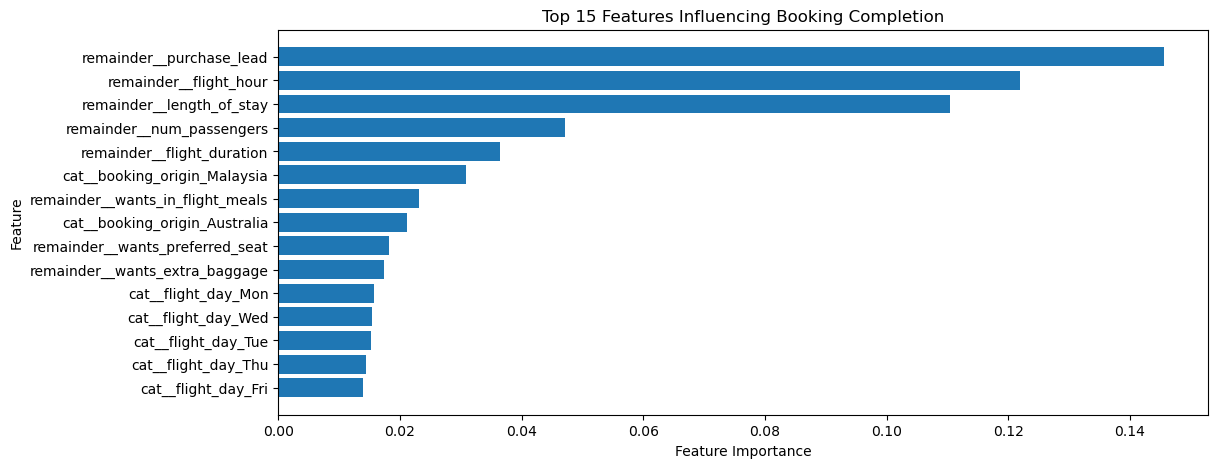

In [60]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(12, 5
                   ))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Booking Completion")

plt.show()

In [61]:
#Create the model performance table
model_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Test ROC-AUC",
        "Mean CV ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob),
        cv_scores.mean()
    ]
})

model_results


,Metric,Score
0,Accuracy,0.848635
1,Precision,0.479042
2,Recall,0.108254
3,F1 Score,0.176600
4,Test ROC-AUC,0.770185
5,Mean CV ROC-AUC,0.778293


### Model Evaluation Summary

The Random Forest model achieved an accuracy of approximately 84.86% and a test ROC-AUC of 0.7702. The mean ROC-AUC across 5-fold stratified cross-validation was 0.7783, indicating that the model's performance was reasonably stable across different training-validation splits.

However, the recall score was only 10.83%, meaning that the model identified only a small proportion of customers who actually completed their booking. This is mainly influenced by the imbalanced target variable, where approximately 85% of customers did not complete their booking and only 15% completed it.

Therefore, accuracy alone should not be used to judge the model. The Random Forest provides a useful baseline and identifies meaningful booking-related patterns, but further improvements such as threshold tuning may be required to increase recall.